<a href="https://colab.research.google.com/github/baoyongk-a11y/week3/blob/main/steam_word2vec_sgns_experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Steam 리뷰 Word2Vec / SGNS 실험
원본 `code03`의 데이터 형식과 기본 설정을 유지한다. Colab에서 **런타임 → 런타임 유형 변경 → T4 GPU**를 선택하고 순서대로 실행한다. 실행 결과를 캡처하여 `report.md`에 붙인다. 실행 시간은 Colab 상태에 따라 달라진다.

In [ ]:
%pip -q install gensim kiwipiepy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 10.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 113.9 MB/s eta 0:00:00


In [ ]:
import os, random, math, urllib.request
from collections import Counter
import numpy as np, pandas as pd, torch
import torch.nn as nn
import torch.nn.functional as F
from gensim.models import Word2Vec
from kiwipiepy import Kiwi
import matplotlib.pyplot as plt
SEED=42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
device='cuda' if torch.cuda.is_available() else 'cpu'
print('device:',device)
os.makedirs('data',exist_ok=True)
path='data/steam.txt'
if not os.path.exists(path):
    urllib.request.urlretrieve('https://raw.githubusercontent.com/bab2min/corpus/master/sentiment/steam.txt',path)
lines=[]
with open(path,encoding='utf-8') as f:
    for line in f:
        label,review=line.rstrip('\n').split('\t',1)
        if review.strip(): lines.append(review.strip())
kiwi=Kiwi()
tokenized=[kiwi.tokenize(line) for line in lines]
sentences=[[t.form for t in ts] for ts in tokenized]
nouns=Counter(t.form for ts in tokenized for t in ts if t.tag=='NNG' and len(t.form)>1)
counts=Counter(w for s in sentences for w in s)
print('reviews',len(lines),'tokens',sum(map(len,sentences)),'vocab >=3',sum(c>=3 for c in counts.values()))

device: cuda
reviews 100000 tokens 2561455 vocab >=3 15346


## 1. CBOW와 Skip-gram
低频词须为 NNG、长度大于 1、语料中出现 5～10 次。保持除 `sg` 以外的 gensim 参数一致。

In [ ]:
common=dict(vector_size=100,window=5,min_count=3,negative=5,sample=1e-3,epochs=10,seed=SEED,workers=1)
cbow=Word2Vec(sentences,sg=0,**common)
sg=Word2Vec(sentences,sg=1,**common)
high=[w for w,_ in nouns.most_common() if w in sg.wv][:3]
rare=[w for w,c in sorted(nouns.items(),key=lambda x:(-x[1],x[0])) if 5<=c<=10 and w in sg.wv][:3]
assert len(high)==len(rare)==3
print('high:',[(w,nouns[w]) for w in high],'rare:',[(w,nouns[w]) for w in rare])
rows=[]
for q in high+rare:
    for name,m in [('CBOW',cbow),('Skip-gram',sg)]:
        rows.append(dict(word=q,count=nouns[q],group='high' if q in high else 'rare',model=name,neighbors=', '.join(f'{w} ({v:.3f})' for w,v in m.wv.most_similar(q,topn=5))))
df1=pd.DataFrame(rows); display(df1)

high: [('게임', 46336), ('플레이', 6671), ('재미', 4899)] rare: [('가관', 10), ('가지', 10), ('갈고리', 10)]


,word,count,group,model,neighbors
0,게임,46336,high,CBOW,"작품 (0.565), 것 (0.535), 겜 (0.503), 거 (0.493), 상..."
1,게임,46336,high,Skip-gram,"케주얼 (0.717), 머시나리움 (0.666), 소마 (0.665), 왜색 (0...."
2,플레이,6671,high,CBOW,"어택 (0.639), 현자 (0.621), 클리어 (0.610), 킬링 (0.608..."
3,플레이,6671,high,Skip-gram,"플래이 (0.674), 즐겜 (0.626), 즐기 (0.621), 클리어 (0.62..."
4,재미,4899,high,CBOW,"깊이 (0.624), 제미 (0.602), 의미 (0.557), 컨텐츠 (0.548..."
5,재미,4899,high,Skip-gram,"제미 (0.669), 메리트 (0.639), 감흥 (0.617), 알맹이 (0.61..."
6,가관,10,rare,CBOW,"제노버스2 (0.602), 썅년 (0.597), 갸꿀잼 (0.594), 알탭 (0...."
7,가관,10,rare,Skip-gram,"퉷퉷 (0.757), 걔 (0.749), 고약 (0.742), 가지가지 (0.740..."
8,가지,10,rare,CBOW,"군데 (0.587), 번 (0.550), 제치 (0.548), 명 (0.502), ..."
9,가지,10,rare,Skip-gram,"제치 (0.601), 골고루 (0.534), 방면 (0.527), 갈래 (0.519..."


## 2. Window 2 / 5 / 10
相同三个查询词；`window=5` 直接复用上一节的 Skip-gram。根据输出人工标注可替换、同主题、混合或难以判断。

In [ ]:
models={5:sg}
for window in (2,10):
    models[window]=Word2Vec(sentences,sg=1,**{**common,'window':window})
q3=high
rows=[]
for q in q3:
    for window,m in sorted(models.items()):
        rows.append(dict(query=q,window=window,neighbors=', '.join(f'{w} ({v:.3f})' for w,v in m.wv.most_similar(q,topn=5)),judgment='待人工判断'))
df2=pd.DataFrame(rows); display(df2)

,query,window,neighbors,judgment
0,게임,2,"겜 (0.714), 케주얼 (0.671), 껨 (0.669), 암살게임 (0.665...",待人工判断
1,게임,5,"케주얼 (0.717), 머시나리움 (0.666), 소마 (0.665), 왜색 (0....",待人工判断
2,게임,10,"케주얼 (0.705), 머시나리움 (0.688), 정적 (0.687), 알만툴 (0...",待人工判断
3,플레이,2,"플래이 (0.760), 즐기 (0.662), 어택 (0.624), 즐겜 (0.622...",待人工判断
4,플레이,5,"플래이 (0.674), 즐겜 (0.626), 즐기 (0.621), 클리어 (0.62...",待人工判断
5,플레이,10,"실질 (0.669), 0.8 (0.661), 잠깐잠깐 (0.656), 싱겁 (0.6...",待人工判断
6,재미,2,"제미 (0.731), 깊이 (0.669), 알맹이 (0.664), 현실감 (0.66...",待人工判断
7,재미,5,"제미 (0.669), 메리트 (0.639), 감흥 (0.617), 알맹이 (0.61...",待人工判断
8,재미,10,"나무라 (0.618), 제미 (0.614), 메리트 (0.611), 볼륨감 (0.5...",待人工判断


## 3. SGNS K 实验
直接延续原 notebook 的 `WINDOW=3, dim=64, Adam(lr=.01), BATCH=512, EPOCHS=3`；三组 K 各自重新初始化，并设置同一个随机种子。第 0 轮是 **训练前** 的实际损失。训练耗时取决于正样本词对数量。

V 15346 pairs 13974628
K 1 epoch 1 loss 1.297
K 1 epoch 2 loss 1.3047
K 1 epoch 3 loss 1.3074
K 5 epoch 1 loss 2.4781
K 5 epoch 2 loss 2.4678
K 5 epoch 3 loss 2.4634
K 20 epoch 1 loss 3.7433
K 20 epoch 2 loss 3.6991
K 20 epoch 3 loss 3.6932


K,1,5,20
epoch,,,
0,1.386294,4.158883,14.556091
1,1.297038,2.478140,3.743280
2,1.304668,2.467832,3.699062
3,1.307421,2.463443,3.693244


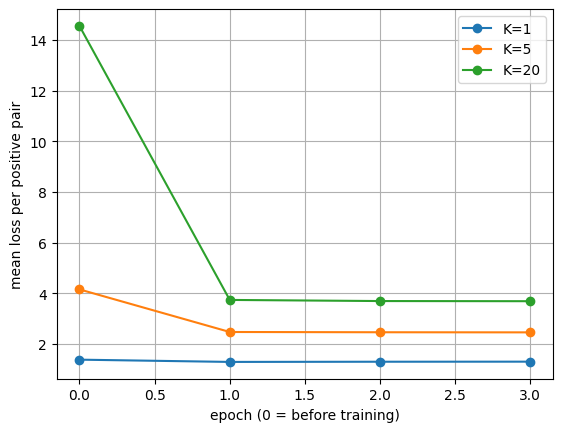

In [ ]:
vocab=[w for w,c in counts.items() if c>=3]; w2i={w:i for i,w in enumerate(vocab)}; V=len(vocab)
ids=[[w2i[w] for w in s if w in w2i] for s in sentences]
WINDOW=3
pairs=[(s[i],s[j]) for s in ids for i in range(len(s)) for j in range(max(0,i-WINDOW),min(len(s),i+WINDOW+1)) if j!=i]
data=torch.tensor(pairs,dtype=torch.long)
noise=torch.tensor([counts[w] for w in vocab],dtype=torch.float).pow(.75)
noise/=noise.sum()
print('V',V,'pairs',len(pairs))
class SGNS(nn.Module):
    def __init__(self,V,dim=64):
        super().__init__()
        self.v=nn.Embedding(V,dim);self.u=nn.Embedding(V,dim)
        nn.init.uniform_(self.v.weight,-.5/dim,.5/dim);nn.init.zeros_(self.u.weight)
    def forward(self,c,o,neg):
        vc=self.v(c);uo=self.u(o);uk=self.u(neg)
        pos=F.logsigmoid((uo*vc).sum(-1))
        neg=F.logsigmoid(-(uk@vc.unsqueeze(-1)).squeeze(-1)).sum(-1)
        return -(pos+neg).mean()
def train_k(K,epochs=3,batch_size=512):
    random.seed(0);torch.manual_seed(0)
    if torch.cuda.is_available():torch.cuda.manual_seed_all(0)
    model=SGNS(V).to(device);opt=torch.optim.Adam(model.parameters(),lr=.01)
    history=[{'K':K,'epoch':0,'loss':(K+1)*math.log(2)}]
    for epoch in range(1,epochs+1):
        perm=torch.randperm(len(data));total=0.
        for start in range(0,len(data),batch_size):
            batch=data[perm[start:start+batch_size]];c,o=batch[:,0].to(device),batch[:,1].to(device)
            neg=torch.multinomial(noise,len(batch)*K,replacement=True).view(len(batch),K).to(device)
            loss=model(c,o,neg);opt.zero_grad();loss.backward();opt.step()
            total+=loss.item()*len(batch)
        history.append({'K':K,'epoch':epoch,'loss':total/len(data)})
        print('K',K,'epoch',epoch,'loss',round(history[-1]['loss'],4))
    return model,history
models_k={};hist=[]
for K in (1,5,20):
    models_k[K],h=train_k(K);hist.extend(h)
df3=pd.DataFrame(hist);display(df3.pivot(index='epoch',columns='K',values='loss'))
for K,g in df3.groupby('K'):
    plt.plot(g.epoch,g.loss,marker='o',label=f'K={K}')
plt.xlabel('epoch (0 = before training)');plt.ylabel('mean loss per positive pair');plt.legend();plt.grid();plt.show()